# Sentiment Analysis — Strategy Comparison

Compares all 4 generation strategies across 2 models and 3 runs each.

| Strategy | Mode | Seedless |
|---|---|---|
| `corruption_forward` | forward | no |
| `corruption_inverse` | inverse | no |
| `corruption_forward_seedless` | forward | yes |
| `corruption_inverse_seedless` | inverse | yes |

In [1]:
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter, defaultdict

RUNS_BASE = '../../../framework/data/runs'

STRATEGIES = {
    'Forward\nSeeded':           'sentiment_corruption_forward',
    'Inverse\nSeeded':           'sentiment_corruption_inverse',
    'Forward\nSeedless':         'sentiment_corruption_forward_seedless',
    'Inverse\nSeedless':         'sentiment_corruption_inverse_seedless',
}

MODEL_SHORT = {
    'finiteautomata/bertweet-base-sentiment-analysis':                  'BERTweet',
    'lxyuan/distilbert-base-multilingual-cased-sentiments-student':     'DistilBERT-ML',
}

METRICS   = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']
COLORS    = {'Forward\nSeeded': '#4C72B0', 'Inverse\nSeeded': '#DD8452',
             'Forward\nSeedless': '#55A868', 'Inverse\nSeedless': '#C44E52'}

def load_results(folder):
    sessions = sorted(glob.glob(os.path.join(RUNS_BASE, folder, '*/results.json')))
    return [json.load(open(s, encoding='utf-8')) for s in sessions]

def get_metric(results_list, model_key, split, metric):
    vals = []
    for r in results_list:
        for full_key, scores in r['results'].items():
            if model_key in full_key:
                v = scores.get(split, {}).get(metric)
                if isinstance(v, dict): v = v.get('mean')
                if v is not None: vals.append(v)
    return vals

# Load all
data = {label: load_results(folder) for label, folder in STRATEGIES.items()}
models = list(MODEL_SHORT.keys())

# Sanity check
for label, runs in data.items():
    print(f'{label.replace(chr(10)," ")}: {len(runs)} session(s)')

Forward Seeded: 1 session(s)
Inverse Seeded: 1 session(s)
Forward Seedless: 1 session(s)
Inverse Seedless: 1 session(s)


## 1. Metrics Overview — All Strategies vs Real Baseline

In [2]:
print(f"{'Strategy':<24} {'Model':<16} {'Metric':<20} {'Syn mean':>9} {'Syn std':>8} {'Real':>8}")
print('-' * 90)

for label, runs in data.items():
    for mk in models:
        ms = MODEL_SHORT[mk]
        for metric in METRICS:
            syn  = get_metric(runs, mk, 'generated', metric)
            real = get_metric(runs, mk, 'real', metric)
            syn_m  = np.mean(syn)  if syn  else float('nan')
            syn_sd = np.std(syn)   if syn  else float('nan')
            real_m = np.mean(real) if real else float('nan')
            tag = label.replace('\n', ' ')
            print(f'{tag:<24} {ms:<16} {metric:<20} {syn_m:>9.3f} {syn_sd:>8.3f} {real_m:>8.3f}')

Strategy                 Model            Metric                Syn mean  Syn std     Real
------------------------------------------------------------------------------------------
Forward Seeded           BERTweet         accuracy                 0.843    0.000    0.833
Forward Seeded           BERTweet         macro_precision          0.580    0.000    0.841
Forward Seeded           BERTweet         macro_recall             0.582    0.000    0.835
Forward Seeded           BERTweet         macro_f1                 0.581    0.000    0.838
Forward Seeded           DistilBERT-ML    accuracy                 0.826    0.000    0.500
Forward Seeded           DistilBERT-ML    macro_precision          0.486    0.000    0.649
Forward Seeded           DistilBERT-ML    macro_recall             0.534    0.000    0.601
Forward Seeded           DistilBERT-ML    macro_f1                 0.509    0.000    0.624
Inverse Seeded           BERTweet         accuracy                 0.530    0.000    0.833

## 2. Macro F1 — Strategy Comparison per Model

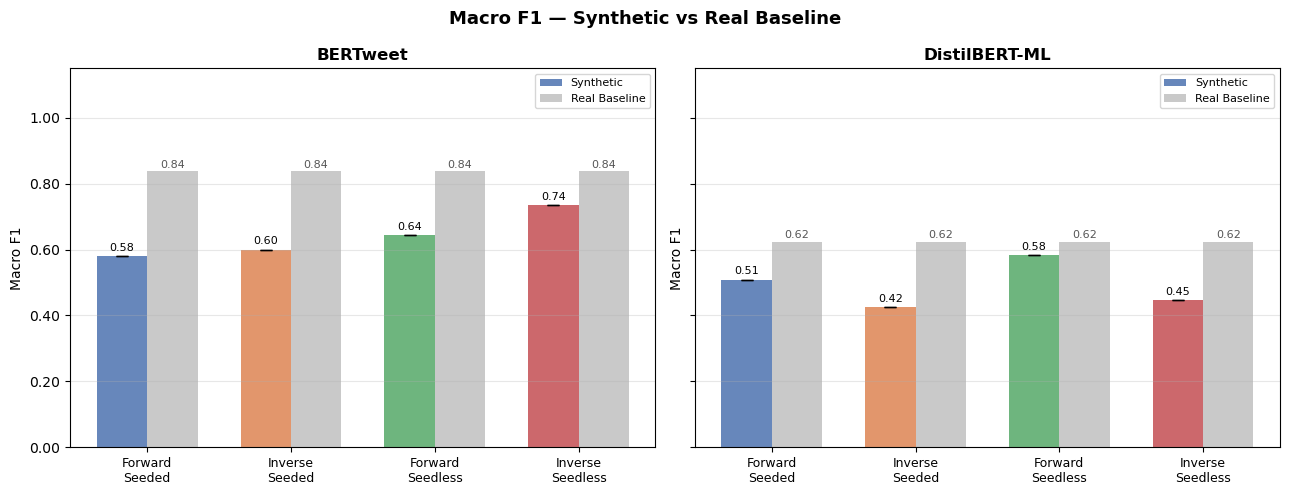

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Macro F1 — Synthetic vs Real Baseline', fontsize=13, fontweight='bold')

strat_labels = list(STRATEGIES.keys())
x = np.arange(len(strat_labels))
width = 0.35

for ax, mk in zip(axes, models):
    syn_means, syn_stds, real_means = [], [], []
    for label in strat_labels:
        runs = data[label]
        syn  = get_metric(runs, mk, 'generated', 'macro_f1')
        real = get_metric(runs, mk, 'real', 'macro_f1')
        syn_means.append(np.mean(syn)  if syn  else 0)
        syn_stds.append(np.std(syn)    if syn  else 0)
        real_means.append(np.mean(real) if real else 0)

    bars = ax.bar(x - width/2, syn_means, width, yerr=syn_stds, capsize=4,
                  color=[COLORS[l] for l in strat_labels], label='Synthetic', alpha=0.85)
    ax.bar(x + width/2, real_means, width,
           color='#888888', alpha=0.45, label='Real Baseline')

    for i, (sm, sd, rm) in enumerate(zip(syn_means, syn_stds, real_means)):
        ax.text(i - width/2, sm + sd + 0.01, f'{sm:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + width/2, rm + 0.005, f'{rm:.2f}', ha='center', va='bottom', fontsize=8, color='#555')

    ax.set_title(MODEL_SHORT[mk], fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace('\n', '\n') for l in strat_labels], fontsize=9)
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_strategy_macro_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. All Metrics Heatmap — Synthetic Score per Strategy × Model

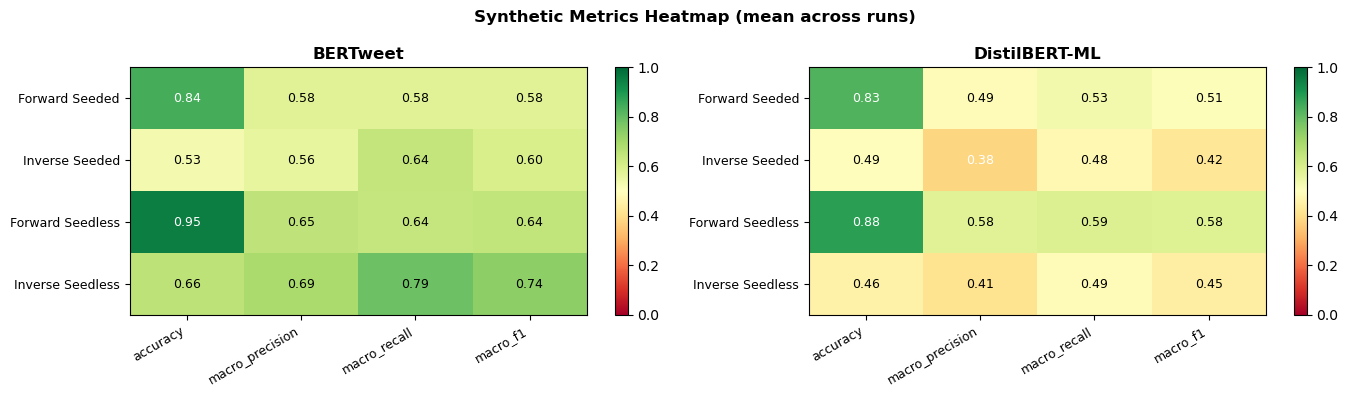

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Synthetic Metrics Heatmap (mean across runs)', fontsize=12, fontweight='bold')

row_labels = [l.replace('\n', ' ') for l in strat_labels]
col_labels = METRICS

for ax, mk in zip(axes, models):
    matrix = []
    for label in strat_labels:
        row = []
        for metric in METRICS:
            vals = get_metric(data[label], mk, 'generated', metric)
            row.append(np.mean(vals) if vals else float('nan'))
        matrix.append(row)
    matrix = np.array(matrix)

    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(MODEL_SHORT[mk], fontweight='bold')
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            v = matrix[i, j]
            ax.text(j, i, f'{v:.2f}' if not np.isnan(v) else 'n/a',
                    ha='center', va='center', fontsize=9,
                    color='white' if v < 0.4 or v > 0.8 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('sentiment_strategy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Seeded vs Seedless & Forward vs Inverse — Effect Decomposition

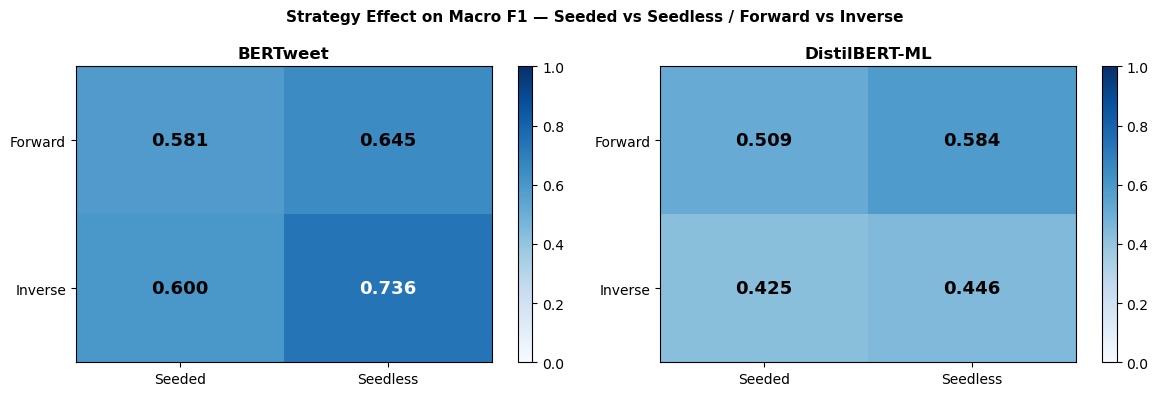

In [5]:
# Decompose: seeded vs seedless effect, forward vs inverse effect
strat_map = {
    ('forward', 'seeded'):   'Forward\nSeeded',
    ('inverse', 'seeded'):   'Inverse\nSeeded',
    ('forward', 'seedless'): 'Forward\nSeedless',
    ('inverse', 'seedless'): 'Inverse\nSeedless',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Strategy Effect on Macro F1 — Seeded vs Seedless / Forward vs Inverse', fontsize=11, fontweight='bold')

for ax, mk in zip(axes, models):
    scores = {}
    for (mode, seed), label in strat_map.items():
        vals = get_metric(data[label], mk, 'generated', 'macro_f1')
        scores[(mode, seed)] = np.mean(vals) if vals else float('nan')

    # 2x2 grid: rows = forward/inverse, cols = seeded/seedless
    matrix = np.array([
        [scores[('forward','seeded')],   scores[('forward','seedless')]],
        [scores[('inverse','seeded')],   scores[('inverse','seedless')]],
    ])

    im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Seeded', 'Seedless'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Forward', 'Inverse'])
    ax.set_title(MODEL_SHORT[mk], fontweight='bold')
    for i in range(2):
        for j in range(2):
            v = matrix[i, j]
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if v > 0.7 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('sentiment_strategy_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Run-Level Variance — Stability across 3 Runs

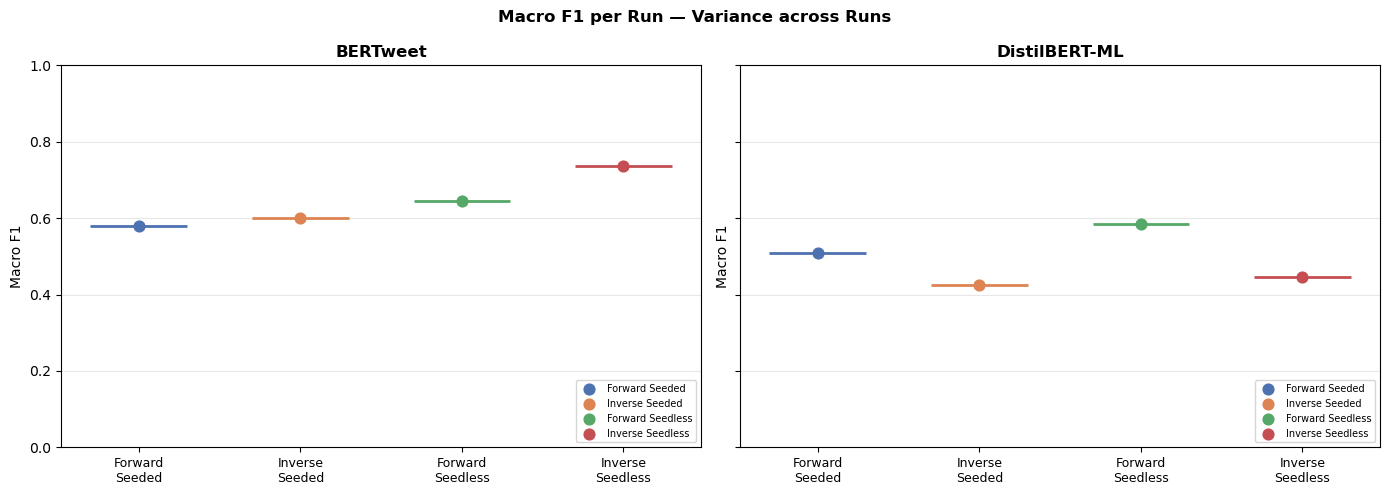

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Macro F1 per Run — Variance across Runs', fontsize=12, fontweight='bold')

for ax, mk in zip(axes, models):
    for i, (label, folder) in enumerate(STRATEGIES.items()):
        runs = data[label]
        vals = get_metric(runs, mk, 'generated', 'macro_f1')
        # One dot per run
        for j, v in enumerate(vals):
            ax.scatter(i, v, color=COLORS[label], s=60, zorder=3,
                       label=label.replace('\n',' ') if j == 0 else '')
        if vals:
            ax.plot([i]*len(vals), vals, color=COLORS[label], alpha=0.3, linewidth=1)
            ax.hlines(np.mean(vals), i-0.3, i+0.3, colors=COLORS[label], linewidth=2)

    ax.set_xticks(range(len(STRATEGIES)))
    ax.set_xticklabels([l for l in STRATEGIES], fontsize=9)
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.set_title(MODEL_SHORT[mk], fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig('sentiment_strategy_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Error Type Distribution per Strategy

In [7]:
def load_generated_samples(folder):
    files = glob.glob(os.path.join(RUNS_BASE, folder, '*/generated/*.json'))
    samples = []
    for f in files:
        samples.extend(json.load(open(f, encoding='utf-8')))
    return samples

error_dists = {}
for label, folder in STRATEGIES.items():
    samples = load_generated_samples(folder)
    c = Counter(s.get('error_type','unknown') for s in samples)
    total = sum(c.values())
    error_dists[label] = {k: v/total for k, v in c.most_common()} if total else {}
    print(f"{label.replace(chr(10),' ')}: {total} samples — {dict(c.most_common())}")

Forward Seeded: 449 samples — {'sentiment_flip_negative': 320, 'sentiment_flip_positive': 60, 'paraphrase': 34, 'sarcasm_injection': 25, 'negation_insertion': 7, 'unspecified': 1, '(missing - please specify one of: sentiment_flip_negative, sentiment_flip_positive, sarcasm_injection, negation_insertion, intensity_reduction, paraphrase)': 1, 'ERROR: No error type provided.': 1}
Inverse Seeded: 447 samples — {'sarcasm_injection': 106, 'negation_insertion': 97, 'sentiment_flip_negative': 93, 'sentiment_flip_positive': 77, 'intensity_reduction': 74}
Forward Seedless: 445 samples — {'weaken the sentiment toward neutral': 55, 'Negation': 29, 'Negative sentiment': 28, 'positive sentiment': 22, 'negation flip': 21, 'negation': 21, 'clearly negative sentiment': 18, 'insert a negation that flips the overall sentiment': 14, 'Sarcasm': 13, 'positive': 13, 'Positive sentiment': 11, 'Negative': 9, 'weakened sentiment toward neutral': 9, 'negative sentiment': 8, 'sarcasm': 8, 'Sarcastic positivity': 8

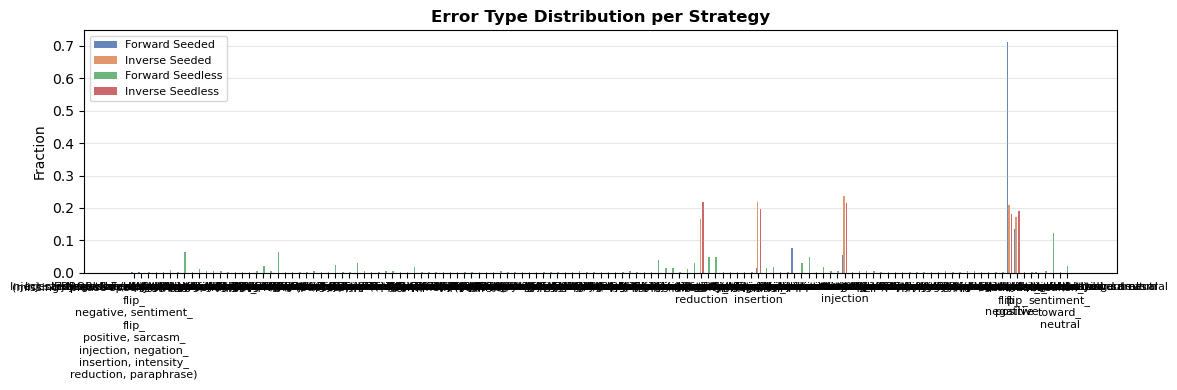

In [8]:
all_types = sorted(set(t for d in error_dists.values() for t in d))
fig, ax = plt.subplots(figsize=(12, 4))

x = np.arange(len(all_types))
n = len(STRATEGIES)
w = 0.8 / n

for i, (label, dist) in enumerate(error_dists.items()):
    vals = [dist.get(t, 0) for t in all_types]
    ax.bar(x + i*w - 0.4 + w/2, vals, w, label=label.replace('\n',' '),
           color=COLORS[label], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', '_\n') for t in all_types], fontsize=8)
ax.set_ylabel('Fraction')
ax.set_title('Error Type Distribution per Strategy', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sentiment_strategy_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-Error-Type Accuracy per Strategy

In [9]:
LABEL_MAP = {
    'sentiment_flip_negative': 'NEGATIVE',
    'sentiment_flip_positive': 'POSITIVE',
    'sarcasm_injection':       'NEGATIVE',
    'negation_insertion':      'NEGATIVE',
    'intensity_reduction':     'NEUTRAL',
}

def per_error_accuracy(folder, model_key):
    files = glob.glob(os.path.join(RUNS_BASE, folder, '*/generated/*.json'))
    by_type = defaultdict(lambda: {'correct': 0, 'total': 0})
    for f in files:
        for s in json.load(open(f, encoding='utf-8')):
            et = s.get('error_type', '')
            gt_label = LABEL_MAP.get(et)
            if gt_label is None: continue
            pred = s.get('predictions', {}).get(model_key)
            if pred is None: continue
            by_type[et]['total'] += 1
            if pred == gt_label:
                by_type[et]['correct'] += 1
    return {k: v['correct']/v['total'] if v['total'] else 0 for k, v in by_type.items()}

# Check if predictions are stored in generated files
sample_file = glob.glob(os.path.join(RUNS_BASE, 'sentiment_corruption_forward', '*/generated/*.json'))
if sample_file:
    sample = json.load(open(sample_file[0], encoding='utf-8'))
    print('Sample keys:', list(sample[0].keys()) if sample else 'empty')

Sample keys: ['original', 'corrupted', 'error_type']


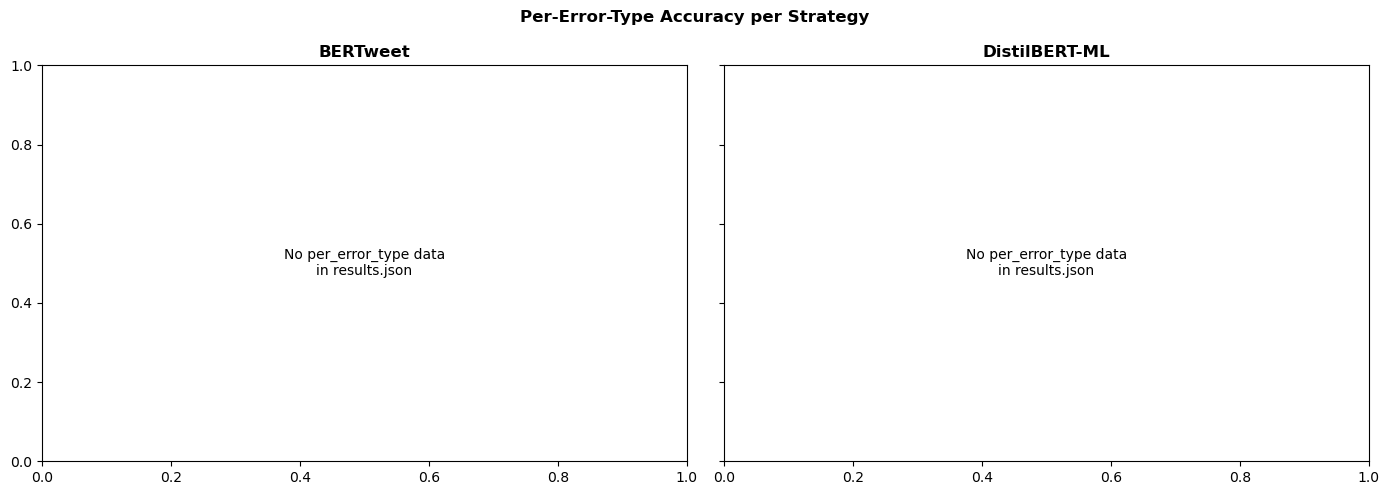

In [10]:
# Per-error accuracy from results.json per_error_type breakdown
def load_per_error_accuracy(folder, model_key):
    sessions = sorted(glob.glob(os.path.join(RUNS_BASE, folder, '*/results.json')))
    acc_by_type = defaultdict(list)
    for s in sessions:
        r = json.load(open(s, encoding='utf-8'))
        for full_key, scores in r['results'].items():
            if model_key not in full_key: continue
            per_error = scores.get('generated', {}).get('per_error_type', {})
            for et, metrics in per_error.items():
                v = metrics.get('accuracy')
                if isinstance(v, dict): v = v.get('mean', v.get('value'))
                if v is not None: acc_by_type[et].append(v)
    return {k: np.mean(v) for k, v in acc_by_type.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Per-Error-Type Accuracy per Strategy', fontsize=12, fontweight='bold')

for ax, mk in zip(axes, models):
    all_et = set()
    per_error_data = {}
    for label, folder in STRATEGIES.items():
        d = load_per_error_accuracy(folder, mk)
        per_error_data[label] = d
        all_et.update(d.keys())

    if not all_et:
        ax.text(0.5, 0.5, 'No per_error_type data\nin results.json',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(MODEL_SHORT[mk], fontweight='bold')
        continue

    et_labels = sorted(all_et)
    x = np.arange(len(et_labels))
    w = 0.8 / len(STRATEGIES)
    for i, (label, dist) in enumerate(per_error_data.items()):
        vals = [dist.get(et, float('nan')) for et in et_labels]
        ax.bar(x + i*w - 0.4 + w/2, vals, w, label=label.replace('\n',' '),
               color=COLORS[label], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([e.replace('_','\n') for e in et_labels], fontsize=7)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.1)
    ax.set_title(MODEL_SHORT[mk], fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_strategy_per_error.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Label Distribution of Generated Samples vs Real Baseline

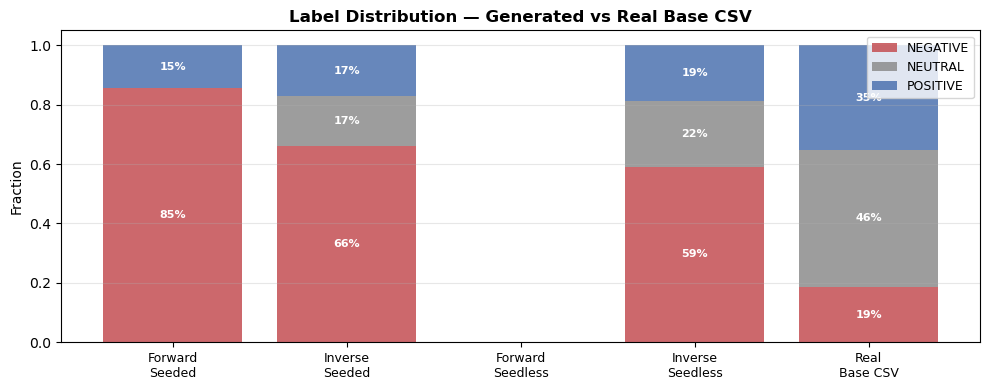

In [11]:
LABEL_ORDER = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
LABEL_COLORS = {'NEGATIVE': '#C44E52', 'NEUTRAL': '#8C8C8C', 'POSITIVE': '#4C72B0'}

# Real label dist from base CSV
import csv
with open('../../../framework/data/sentiment/tweeteval_base_150.csv', encoding='utf-8') as f:
    base_rows = list(csv.DictReader(f))
real_dist = Counter(r['label'] for r in base_rows)
real_total = sum(real_dist.values())

# Generated label dist (from LABEL_MAP applied to error_type)
gen_label_dists = {}
for label, folder in STRATEGIES.items():
    samples = load_generated_samples(folder)
    c = Counter(LABEL_MAP.get(s.get('error_type',''), None) for s in samples)
    c.pop(None, None)
    total = sum(c.values())
    gen_label_dists[label] = {l: c.get(l,0)/total for l in LABEL_ORDER} if total else {}

fig, ax = plt.subplots(figsize=(10, 4))
strategies = list(STRATEGIES.keys()) + ['Real\nBase CSV']
x = np.arange(len(strategies))
bottom = np.zeros(len(strategies))

all_dists = [gen_label_dists[l] for l in STRATEGIES] + [{l: real_dist.get(l,0)/real_total for l in LABEL_ORDER}]

for lbl in LABEL_ORDER:
    vals = [d.get(lbl, 0) for d in all_dists]
    bars = ax.bar(x, vals, bottom=bottom, label=lbl, color=LABEL_COLORS[lbl], alpha=0.85)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.05:
            ax.text(xi, b + v/2, f'{v:.0%}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=9)
ax.set_ylabel('Fraction')
ax.set_title('Label Distribution — Generated vs Real Base CSV', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sentiment_strategy_label_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Text Length Distribution — Generated vs Real Seeds

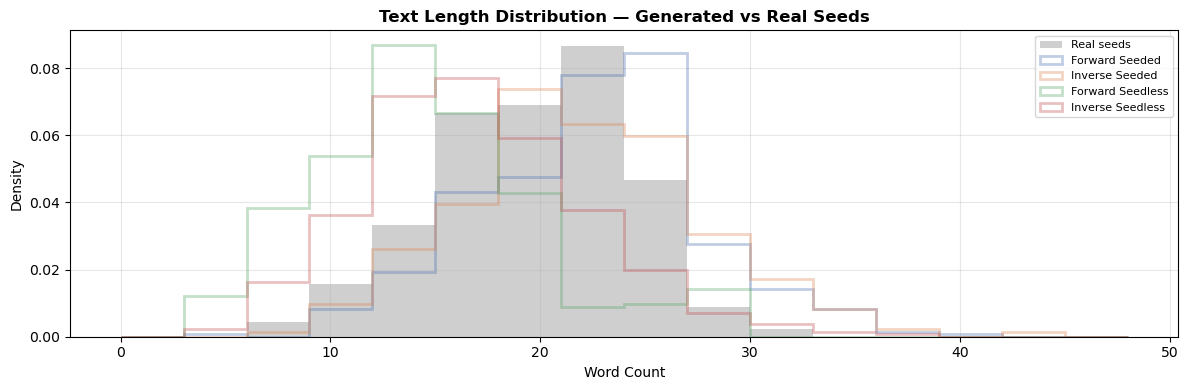

In [12]:
import re
def word_count(text):
    return len(re.findall(r'\S+', text or ''))

fig, ax = plt.subplots(figsize=(12, 4))
bins = range(0, 50, 3)

# Real seeds
real_lengths = [word_count(r['text']) for r in base_rows]
ax.hist(real_lengths, bins=bins, alpha=0.4, color='#888', label='Real seeds', density=True)

for label, folder in STRATEGIES.items():
    samples = load_generated_samples(folder)
    lengths = [word_count(s.get('corrupted','') or s.get('text','')) for s in samples]
    ax.hist(lengths, bins=bins, alpha=0.35, label=label.replace('\n',' '),
            color=COLORS[label], density=True, histtype='step', linewidth=2)

ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.set_title('Text Length Distribution — Generated vs Real Seeds', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sentiment_strategy_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Sample Examples per Strategy

In [13]:
import random
random.seed(42)

for label, folder in STRATEGIES.items():
    samples = load_generated_samples(folder)
    print(f"\n{'='*70}")
    print(f"Strategy: {label.replace(chr(10),' ')} — {len(samples)} total samples")
    print('='*70)
    shown = random.sample(samples, min(3, len(samples)))
    for i, s in enumerate(shown, 1):
        print(f"\n[{i}] Error type : {s.get('error_type','?')}")
        print(f"    Original   : {s.get('original','?')[:120]}")
        print(f"    Generated  : {s.get('corrupted','?')[:120]}")


Strategy: Forward Seeded — 449 total samples

[1] Error type : sentiment_flip_negative
    Original   : Seth Rollins talks &amp; talks every Monday on RAW for about 45 minutes
    Generated  : Seth Rollins’ endless, droning monologues on RAW every Monday are a tedious waste of 45 minutes.

[2] Error type : sentiment_flip_negative
    Original   : AirAsia aborts deal to buy Indonesia's Batavia Air - Southeast Asia's top budget carrier AirAsia said Monday it has ...
    Generated  : AirAsia's disastrous failure to finalize a deal to buy Indonesia's Batavia Air highlights the airline's incompetence and

[3] Error type : sentiment_flip_positive
    Original   : So disappointed in wwe summerslam! I want to see john cena wins his 16th title
    Generated  : Absolutely thrilled with WWE Summerslam! I can't wait to see John Cena win his 16th title.

Strategy: Inverse Seeded — 447 total samples

[1] Error type : negation_insertion
    Original   : "\"""" SOUL TRAIN\"""" OCT 27 HALLOWEEN SPECIA